# Bangkok Rain-Any Neighbor Models (V1)

Bangkok port of `Thailand_Rain_V1.ipynb`, reading `"OM_BKK_DATA_PRECOMPUTE"` (built by
`OM_Script/precompute_om_bkk_features.py` from `"OM_BKK_DATA"`) instead of the national
25 km panel. Every shared cell is unchanged apart from table names and labels.

Models trained:

- `1h`: LightGBM
- `2h`: LightGBM
- `3h`: HistGradientBoosting
- `6h`: HistGradientBoosting

## Why this exists alongside `bkk_final_4_rain_any_neighbor_models.ipynb`

That notebook trains the same four models on the same Bangkok data, but it has two
methodology problems that `Thailand_Rain_V1.ipynb` fixed. This notebook is the Bangkok
version with those fixes, so Bangkok and Thailand results now come from the same method
and can be compared directly.

1. **Operating thresholds were fitted on the test split.** The old notebook hardcodes
   `{1: 0.60, 2: 0.50, 3: 0.30, 6: 0.30}`. Those are exactly the best-F1 thresholds *on
   the test set*, and all four differ from the best-on-validation values
   (`0.65, 0.60, 0.35, 0.35`). Selecting on test means test is no longer a clean holdout.
   Here the threshold is chosen on validation and applied once to test. The measured cost
   on Bangkok is small (+0.002 to +0.008 F1), but the habit matters.
2. **HistGradientBoosting silently early-stopped on a random split.** The old notebook
   left `early_stopping` at its default `"auto"`, which switches itself on above 10,000
   rows and builds its internal validation slice with a *random* `train_test_split`. On an
   hourly panel that leaks future hours into the stopping decision. Section 6 already holds
   out a chronological validation split, so `early_stopping=False` is set here and the
   3h/6h models run all 250 iterations deterministically.

Two notes specific to this port:

3. **No panel truncation.** Thailand had to stop at 2026-06-25 because only 100 of its 833
   grids reported past that date. All 56 Bangkok grids span 2021-07-20 to 2026-07-19
   identically, so the full panel is used. Section 4 asserts this rather than assuming it.
   (The Thailand notebook header describes Bangkok as "96 grids at 9 km"; it is 56.)
4. **Bangkok has five years of history against Thailand's eleven months.** This is the most
   important practical difference. The splits here cover several full wet/dry cycles, so
   the test period resembles something the model has seen before. Treat the Thailand
   numbers as far less settled than these.

## Read this before trusting the numbers

The `rain_any_next_{h}h` targets come from Open-Meteo's `precipitation` field, which is
ECMWF **model output**, not observed rain. Measured across the 2.45M-row join to
`"IMERG_BKK_DATA"`, the two disagree substantially: correlation 0.175, and the diurnal
cycles sit about five hours apart (Open-Meteo peaks at 15:00 local, IMERG at 20:00).

Re-scoring the previously saved 1h/2h models against IMERG dropped ROC-AUC from 0.933 to
0.773 and precision from 0.668 to 0.261 at +1h. Section 11 runs that same check on the
models trained here. It is optional and read-only, but the headline numbers in sections
8-9 measure agreement with a weather model, not with observed rainfall.

## 1. Setup

In [1]:
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
IMERG_TABLE_NAME = '"IMERG_BKK_DATA"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_v1"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

# Thresholds hardcoded by bkk_final_4_rain_any_neighbor_models.ipynb, kept for a
# side-by-side comparison only. They were fitted on that notebook's test split.
LEGACY_PROBABILITY_THRESHOLDS = {
    1: 0.60,
    2: 0.50,
    3: 0.30,
    6: 0.30,
}
MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick smoke tests: 300_000
RANDOM_STATE = 42

# Both predecessor notebooks hand LightGBM a validation set with no early-stopping
# callback, so it only logs and every model gets exactly 500 trees. Enabling this lets
# the chronological validation split from section 6 decide the tree count - the same
# "use the honest holdout" reasoning behind early_stopping=False on the HGB models.
# Set to False for exact parity with Thailand_Rain_V1.
USE_LIGHTGBM_EARLY_STOPPING = True
LIGHTGBM_N_ESTIMATORS = 1500
LIGHTGBM_EARLY_STOPPING_ROUNDS = 60

# Section 11 only: read-only re-scoring against observed satellite rainfall.
RUN_IMERG_AUDIT = True

print(f"Source table    : {PRECOMPUTE_TABLE_NAME}")
print(f"Horizons        : {HORIZONS}")
print(f"LGBM early stop : {USE_LIGHTGBM_EARLY_STOPPING}")

Source table    : "OM_BKK_DATA_PRECOMPUTE"
Horizons        : [1, 2, 3, 6]
LGBM early stop : True


## 3. Feature Columns

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"Targets: {TARGET_COLUMNS}")

Features used: 66
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load Precomputed Training Data

Bangkok is roughly 2.45M rows x 66 features, which fits in memory far more comfortably
than the Thailand panel. The streaming `float32` loader is kept anyway: it avoids the
~1.3 GB `float64` intermediate `pd.read_sql_query` would build, and it keeps this notebook
directly comparable with `Thailand_Rain_V1.ipynb`.

Rows arrive ordered by `(local_forecast_time, grid_number)`, which is what makes the
chronological splits in section 6 free.

In [4]:
ROW_FILTER_SQL = f'''
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
'''


def connect():
    return psycopg2.connect(**DB_CONFIG)


def count_training_rows(conn):
    with conn.cursor() as cur:
        cur.execute(f"SELECT count(*) FROM {PRECOMPUTE_TABLE_NAME} {ROW_FILTER_SQL}")
        return cur.fetchone()[0]


def read_training_data(sample_rows=None, batch_size=250_000):
    """Stream the training panel into preallocated float32 / int8 arrays.

    Returns (x, y, forecast_time, grid_number). Feature and target casting happens
    server-side so psycopg2 never materialises a float64 Python object per cell.
    """
    # COALESCE to NaN: psycopg2 hands back None for SQL NULL, which cannot be cast
    # into a float32 array. Both LightGBM and HistGradientBoosting handle NaN natively.
    feature_sql = ",\n        ".join(
        f"COALESCE({c}::real, 'NaN'::real) AS {c}" for c in FEATURE_COLUMNS
    )
    target_sql = ",\n        ".join(f"{t}::smallint" for t in TARGET_COLUMNS)
    query = f'''
    SELECT
        grid_number,
        local_forecast_time,
        {feature_sql},
        {target_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    {ROW_FILTER_SQL}
    ORDER BY local_forecast_time, grid_number
    '''

    with connect() as conn:
        total_rows = count_training_rows(conn)
        n_rows = min(total_rows, sample_rows) if sample_rows else total_rows
        if sample_rows:
            query += f"\n    LIMIT {int(sample_rows)}"
        print(f"Allocating {n_rows:,} rows x {len(FEATURE_COLUMNS)} features "
              f"({n_rows * len(FEATURE_COLUMNS) * 4 / 1e9:.2f} GB float32)")

        x = np.empty((n_rows, len(FEATURE_COLUMNS)), dtype="float32")
        y = np.empty((n_rows, len(TARGET_COLUMNS)), dtype="int8")
        forecast_time = np.empty(n_rows, dtype="datetime64[s]")
        grid_number = np.empty(n_rows, dtype="int32")

        n_feat = len(FEATURE_COLUMNS)
        filled = 0
        with conn.cursor(name="bkk_training_stream") as cur:
            cur.itersize = batch_size
            cur.execute(query)
            while filled < n_rows:
                batch = cur.fetchmany(batch_size)
                if not batch:
                    break
                block = np.asarray(batch, dtype="object")
                take = min(len(batch), n_rows - filled)
                grid_number[filled:filled + take] = block[:take, 0].astype("int32")
                forecast_time[filled:filled + take] = block[:take, 1].astype("datetime64[s]")
                x[filled:filled + take] = block[:take, 2:2 + n_feat].astype("float32")
                y[filled:filled + take] = block[:take, 2 + n_feat:].astype("int8")
                filled += take
                print(f"  loaded {filled:,} / {n_rows:,}", end="\r", flush=True)
        print()

    if filled != n_rows:
        x, y = x[:filled], y[:filled]
        forecast_time, grid_number = forecast_time[:filled], grid_number[:filled]
    return x, y, forecast_time, grid_number

In [5]:
x_all, y_all, forecast_time, grid_number = read_training_data(SAMPLE_ROWS)

print(f"x: {x_all.shape}  y: {y_all.shape}")
print(f"{forecast_time.min()} to {forecast_time.max()}")
print(f"grids: {np.unique(grid_number).size}")
print(f"x memory: {x_all.nbytes / 1e9:.2f} GB")

nan_counts = np.isnan(x_all).sum(axis=0)
if nan_counts.any():
    display(pd.Series(nan_counts, index=FEATURE_COLUMNS).loc[lambda s: s > 0].sort_values(ascending=False))
else:
    print("No NaNs in feature matrix.")

# Thailand needed a panel truncation because only 100 of 833 grids ran to the end.
# Bangkok should need none - verify rather than assume.
grid_spans = pd.DataFrame({"grid_number": grid_number, "forecast_time": forecast_time}).groupby(
    "grid_number")["forecast_time"].agg(["min", "max"])
print(f"grids: {len(grid_spans)}  identical start: {grid_spans['min'].nunique() == 1}  "
      f"identical end: {grid_spans['max'].nunique() == 1}")
if grid_spans["min"].nunique() != 1 or grid_spans["max"].nunique() != 1:
    print("WARNING: grids do not span the same window; a truncation step is needed.")

display(pd.DataFrame(x_all[:5], columns=FEATURE_COLUMNS).assign(
    grid_number=grid_number[:5], forecast_time=forecast_time[:5]))

Allocating 2,453,568 rows x 66 features (0.65 GB float32)


x: (2453568, 66)  y: (2453568, 4)


2021-07-20T06:00:00 to 2026-07-19T21:00:00
grids: 56
x memory: 0.65 GB


No NaNs in feature matrix.
grids: 56  identical start: True  identical end: False


,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,temperature_dew_point_spread,pressure_msl_change_3h,pressure_msl_change_6h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_12h,precipitation_sum_past_24h,cloud_cover_lag_1h,cloud_cover_lag_3h,cloud_cover_lag_6h,humidity_lag_1h,humidity_lag_3h,humidity_lag_6h,wind_speed_lag_1h,wind_speed_lag_3h,hour_sin,hour_cos,month_sin,month_cos,grid_row,grid_column,latitude,longitude,neighbor_count,neighbor_precipitation_mean,neighbor_precipitation_max,neighbor_precipitation_sum,neighbor_rain_count,neighbor_rain_rate,neighbor_cloud_cover_mean,neighbor_cloud_cover_max,neighbor_relative_humidity_mean,neighbor_relative_humidity_max,neighbor_pressure_msl_mean,neighbor_pressure_msl_min,neighbor_pressure_msl_max,neighbor_temperature_2m_mean,neighbor_dew_point_2m_mean,neighbor_temperature_dew_point_spread_mean,neighbor_wind_speed_10m_mean,neighbor_wind_speed_10m_max,row_minus_precipitation_mean,row_plus_precipitation_mean,column_minus_precipitation_mean,column_plus_precipitation_mean,row_minus_cloud_cover_mean,row_plus_cloud_cover_mean,column_minus_cloud_cover_mean,column_plus_cloud_cover_mean,neighbor_precipitation_mean_minus_center,neighbor_cloud_cover_mean_minus_center,neighbor_relative_humidity_mean_minus_center,center_pressure_msl_minus_neighbor_mean,grid_number,forecast_time
0,26.4000,87.0000,1005.6000,1005.4000,24.0000,2.4000,100.0000,18.0000,217.0000,2.4000,-0.3000,-1.8000,1.7000,1.0000,0.6000,0.3000,5.1000,6.2000,6.5000,6.5000,99.0000,99.0000,99.0000,87.0000,87.0000,87.0000,19.7000,19.9000,1.0000,0.0000,-0.5000,-0.8660,1.0000,1.0000,13.4940,100.3270,3.0000,2.2667,2.5000,6.8000,3.0000,1.0000,100.0000,100.0000,88.0000,90.0000,1005.6334,1005.6000,1005.7000,26.1667,23.9333,2.2333,15.8667,19.2000,0.0000,2.4000,0.0000,2.1500,100.0000,100.0000,100.0000,100.0000,-0.1333,0.0000,1.0000,-0.0333,1,2021-07-20 06:00:00
1,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1.0000,2.0000,13.4940,100.4102,5.0000,2.2800,2.5000,11.4000,5.0000,1.0000,100.0000,100.0000,87.8000,90.0000,1005.6400,1005.6000,1005.7000,26.2200,23.9800,2.2400,16.4400,19.2000,0.0000,2.3333,2.4500,2.1000,100.0000,100.0000,100.0000,100.0000,0.2800,0.0000,2.8000,0.0600,2,2021-07-20 06:00:00
2,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1.0000,3.0000,13.4940,100.4934,5.0000,1.9400,2.3000,9.7000,5.0000,1.0000,100.0000,100.0000,86.8000,89.0000,1005.7000,1005.6000,1005.8000,26.4000,23.9800,2.4200,17.2600,19.2000,0.0000,2.1000,2.1500,1.6000,100.0000,100.0000,100.0000,100.0000,-0.0600,0.0000,1.8000,0.0000,3,2021-07-20 06:00:00
3,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,-1.7000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,2.7000,100.0000,100.0000,98.0000,82.0000,79.0000,81.0000,23.2000,21.9000,1.0000,0.0000,-0.5000,-0.8660,1.0000,4.0000,13.4940,100.5767,5.0000,1.7800,2.2000,8.9000,5.0000,1.0000,100.0000,100.0000,86.6000,88.0000,1005.7400,1005.7000,1005.8000,26.4400,24.0000,2.4400,17.4400,19.2000,0.0000,1.8333,2.1000,1.4500,100.0000,100.0000,100.0000,100.0000,0.3800,0.0000,0.6000,0.0600,4,2021-07-20 06:00:00
4,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,-1.7000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,2.7000,100.0000,100.0000,98.0000,82.0000,79.0000,81.0000,23.2000,21.9000,1.0000,0.0000,-0.5000,-0.8660,1.0000,5.0000,13.4940,100.6599,5.000

## 5. Target Balance

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,2453568,541154,0.2206
1,2,rain_any_next_2h,0.1000,2453568,696173,0.2837
2,3,rain_any_next_3h,0.1000,2453568,815989,0.3326
3,6,rain_any_next_6h,0.1000,2453568,1076591,0.4388


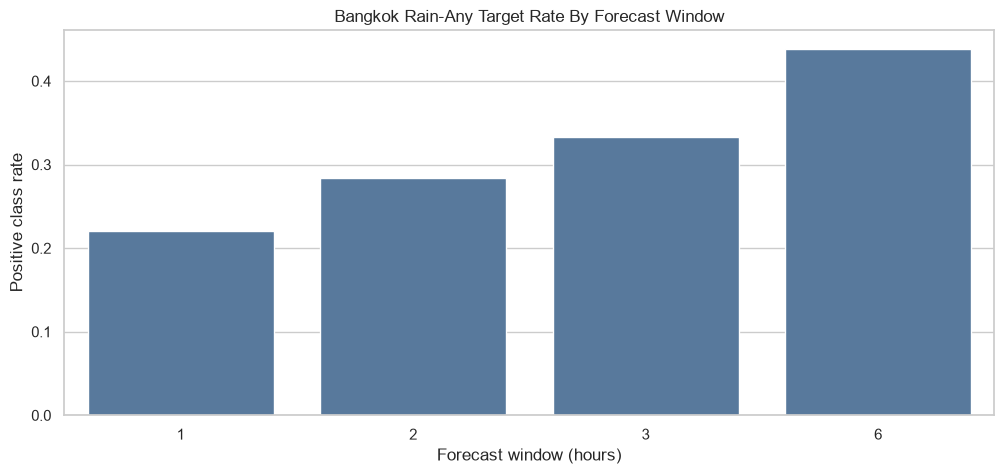

In [6]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": int(y_all.shape[0]),
        "rain_rows": int(y_all[:, i].sum()),
        "rain_rate": float(y_all[:, i].mean()),
    }
    for i, horizon in enumerate(HORIZONS)
])
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8")
plt.title("Bangkok Rain-Any Target Rate By Forecast Window")
plt.xlabel("Forecast window (hours)")
plt.ylabel("Positive class rate")
plt.show()

## 6. Chronological Split

Rows are already ordered by `local_forecast_time`, so each split is a contiguous slice.
`np.searchsorted` finds the boundaries and the splits are numpy **views** - no data is
copied.

Unlike Thailand, Bangkok spans five years, so each split covers whole wet and dry seasons
rather than a fragment of one. The per-split rain rate is printed below anyway, because it
still drifts: a threshold tuned on a wet validation stretch transfers poorly to a drier
test stretch.

In [7]:
def time_split_bounds(times, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.unique(times)
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    train_stop = int(np.searchsorted(times, train_end, side="left"))
    validation_stop = int(np.searchsorted(times, validation_end, side="left"))
    return train_end, validation_end, train_stop, validation_stop


train_end, validation_end, train_stop, validation_stop = time_split_bounds(
    forecast_time, TRAIN_FRACTION, VALIDATION_FRACTION
)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")

x_train, x_validation, x_test = x_all[:train_stop], x_all[train_stop:validation_stop], x_all[validation_stop:]
y_train_all, y_validation_all, y_test_all = y_all[:train_stop], y_all[train_stop:validation_stop], y_all[validation_stop:]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(x_train),
     "from": str(forecast_time[:train_stop].min()), "to": str(forecast_time[:train_stop].max()),
     **{f"rain_rate_{h}h": float(y_train_all[:, i].mean()) for i, h in enumerate(HORIZONS)}},
    {"split": "validation", "rows": len(x_validation),
     "from": str(forecast_time[train_stop:validation_stop].min()), "to": str(forecast_time[train_stop:validation_stop].max()),
     **{f"rain_rate_{h}h": float(y_validation_all[:, i].mean()) for i, h in enumerate(HORIZONS)}},
    {"split": "test", "rows": len(x_test),
     "from": str(forecast_time[validation_stop:].min()), "to": str(forecast_time[validation_stop:].max()),
     **{f"rain_rate_{h}h": float(y_test_all[:, i].mean()) for i, h in enumerate(HORIZONS)}},
])
display(split_summary)
print(f"splits are zero-copy views: {x_train.base is x_all and x_test.base is x_all}")

Train before: 2025-01-18T05:00:00
Validation before: 2025-10-19T01:00:00


,split,rows,from,to,rain_rate_1h,rain_rate_2h,rain_rate_3h,rain_rate_6h
0,train,1717576,2021-07-20T06:00:00,2025-01-18T04:00:00,0.2227,0.2837,0.3306,0.4333
1,validation,368032,2025-01-18T05:00:00,2025-10-19T00:00:00,0.2687,0.3495,0.4111,0.5389
2,test,367960,2025-10-19T01:00:00,2026-07-19T21:00:00,0.1624,0.2184,0.2632,0.3644


splits are zero-copy views: True


## 7. Evaluation Helpers

In [8]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": "neighbor_grid",
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_thresholds(threshold_results, chosen_thresholds, split="test"):
    """Look up metrics at a given operating threshold per horizon."""
    rows = []
    for horizon, threshold in chosen_thresholds.items():
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == MODEL_PLAN[horizon])
            & (threshold_results["split"] == split)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)

## 8. Train Final 4 Models

In [9]:
try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []
train_timings = {}
fitted_iterations = {}

for index, horizon in enumerate(HORIZONS):
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...", flush=True)
    started = time.time()

    y_train = y_train_all[:, index]
    y_validation = y_validation_all[:, index]
    y_test = y_test_all[:, index]

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=LIGHTGBM_N_ESTIMATORS if USE_LIGHTGBM_EARLY_STOPPING else 500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        # Both predecessor notebooks pass validation data here with no early-stopping
        # callback, so it only logs and the tree count is fixed. The callback below makes
        # the chronological holdout actually choose the tree count.
        callbacks = (
            [early_stopping(LIGHTGBM_EARLY_STOPPING_ROUNDS, verbose=False), log_evaluation(0)]
            if USE_LIGHTGBM_EARLY_STOPPING
            else [log_evaluation(0)]
        )
        model.fit(
            x_train,
            y_train,
            eval_set=[(x_validation, y_validation)],
            eval_metric="binary_logloss",
            callbacks=callbacks,
        )
        fitted_iterations[horizon] = int(model.best_iteration_ or model.n_estimators)
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
            # bkk_final_4_rain_any_neighbor_models.ipynb left this at the default "auto",
            # which turns itself on above
            # 10k rows and carves out its validation slice with a *random* train_test_split.
            # On an hourly panel that samples future hours into the stopping criterion, and
            # it copies the raw float32 matrix (~1.3 GB at Thailand scale). Section 6 already
            # holds out a chronological validation split, so stop deterministically instead.
            early_stopping=False,
        )
        model.fit(x_train, y_train)
        fitted_iterations[horizon] = int(model.n_iter_)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model
    train_timings[horizon] = time.time() - started
    print(f"  fitted in {train_timings[horizon] / 60:.1f} min "
          f"({fitted_iterations[horizon]} iterations)", flush=True)

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split, probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)

display(pd.Series(fitted_iterations, name="fitted_iterations").rename_axis("horizon_h").reset_index())
display(all_metrics.sort_values(["horizon_h", "split"]))

Training lightgbm for rain_any_next_1h...


C:\Users\Brandon\Documents\Phase 1\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  fitted in 0.2 min (42 iterations)


Training lightgbm for rain_any_next_2h...


C:\Users\Brandon\Documents\Phase 1\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

  fitted in 0.6 min (250 iterations)


Training hist_gradient_boosting for rain_any_next_6h...


  fitted in 0.5 min (250 iterations)


,horizon_h,fitted_iterations
0,1,42
1,2,1500
2,3,250
3,6,250


,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9255,0.7293,0.0858
0,lightgbm,neighbor_grid,1,validation,368032,0.2687,0.9070,0.7911,0.1227
3,lightgbm,neighbor_grid,2,test,367960,0.2184,0.9118,0.7660,0.0983
2,lightgbm,neighbor_grid,2,validation,368032,0.3495,0.8947,0.8302,0.1364
5,hist_gradient_boosting,neighbor_grid,3,test,367960,0.2632,0.9024,0.7814,0.1084
4,hist_gradient_boosting,neighbor_grid,3,validation,368032,0.4111,0.8862,0.8484,0.1351
7,hist_gradient_boosting,neighbor_grid,6,test,367960,0.3644,0.8928,0.8274,0.1295
6,hist_gradient_boosting,neighbor_grid,6,validation,368032,0.5389,0.8811,0.8932,0.1407


## 8b. Operating Threshold Selection

The threshold is picked on **validation** by best F1, then applied to **test**. This avoids
reporting a threshold that was fitted on the same rows it is scored on.

In [10]:
validation_best = best_by_f1[best_by_f1["split"] == "validation"]
SELECTED_PROBABILITY_THRESHOLDS = {
    int(row.horizon_h): float(row.probability_threshold)
    for row in validation_best.itertuples()
}
print("Selected on validation:", SELECTED_PROBABILITY_THRESHOLDS)
print("Legacy notebook values:", LEGACY_PROBABILITY_THRESHOLDS)

selected_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, SELECTED_PROBABILITY_THRESHOLDS, split="test")
legacy_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, LEGACY_PROBABILITY_THRESHOLDS, split="test")

report_columns = [
    "horizon_h", "model", "probability_threshold", "rain_rate", "predicted_rain_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score",
    "true_positives", "false_positives", "false_negatives", "true_negatives",
]

print("\nTEST metrics at validation-selected thresholds")
display(selected_threshold_metrics[report_columns].sort_values("horizon_h"))

print("\nTEST metrics at legacy Bangkok thresholds (comparison)")
display(legacy_threshold_metrics[report_columns].sort_values("horizon_h"))

print("\nTEST oracle best-F1 thresholds (upper bound, fitted on test - do not deploy)")
display(best_by_f1[best_by_f1["split"] == "test"][report_columns].sort_values("horizon_h"))

Selected on validation: {3: 0.3500000000000001, 6: 0.3500000000000001, 1: 0.6000000000000002, 2: 0.5500000000000002}
Legacy notebook values: {1: 0.6, 2: 0.5, 3: 0.3, 6: 0.3}

TEST metrics at validation-selected thresholds


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
2,1,lightgbm,0.6000,0.1624,0.1656,0.8953,0.6741,0.6877,0.6809,0.9255,0.7293,0.0858,41088,19860,18660,288352
3,2,lightgbm,0.5500,0.2184,0.2178,0.8644,0.6900,0.6882,0.6891,0.9118,0.7660,0.0983,55302,24841,25053,262764
0,3,hist_gradient_boosting,0.3500,0.2632,0.2696,0.8422,0.6955,0.7125,0.7039,0.9024,0.7814,0.1084,68998,30215,27838,240909
1,6,hist_gradient_boosting,0.3500,0.3644,0.3896,0.8111,0.7253,0.7754,0.7495,0.8928,0.8274,0.1295,103983,39391,30115,194471



TEST metrics at legacy Bangkok thresholds (comparison)


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
0,1,lightgbm,0.6000,0.1624,0.1656,0.8953,0.6741,0.6877,0.6809,0.9255,0.7293,0.0858,41088,19860,18660,288352
1,2,lightgbm,0.5000,0.2184,0.2387,0.8595,0.6632,0.7247,0.6926,0.9118,0.7660,0.0983,58236,29581,22119,258024
2,3,hist_gradient_boosting,0.3000,0.2632,0.2971,0.8364,0.6676,0.7538,0.7080,0.9024,0.7814,0.1084,72991,36348,23845,234776
3,6,hist_gradient_boosting,0.3000,0.3644,0.4218,0.8047,0.7005,0.8108,0.7516,0.8928,0.8274,0.1295,108720,46494,25378,187368



TEST oracle best-F1 thresholds (upper bound, fitted on test - do not deploy)


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
26,1,lightgbm,0.5500,0.1624,0.1866,0.8894,0.6388,0.7342,0.6832,0.9255,0.7293,0.0858,43868,24806,15880,283406
59,2,lightgbm,0.5000,0.2184,0.2387,0.8595,0.6632,0.7247,0.6926,0.9118,0.7660,0.0983,58236,29581,22119,258024
89,3,hist_gradient_boosting,0.3000,0.2632,0.2971,0.8364,0.6676,0.7538,0.7080,0.9024,0.7814,0.1084,72991,36348,23845,234776
123,6,hist_gradient_boosting,0.3000,0.3644,0.4218,0.8047,0.7005,0.8108,0.7516,0.8928,0.8274,0.1295,108720,46494,25378,187368


## 9. Results Charts

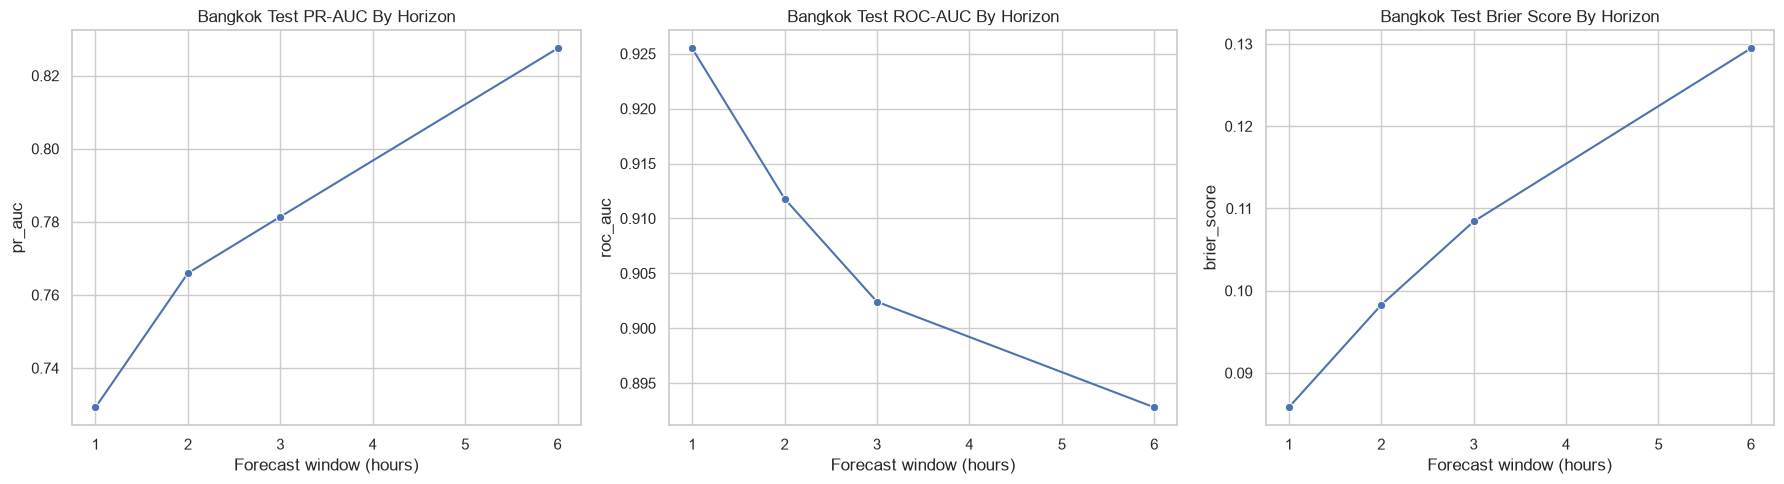

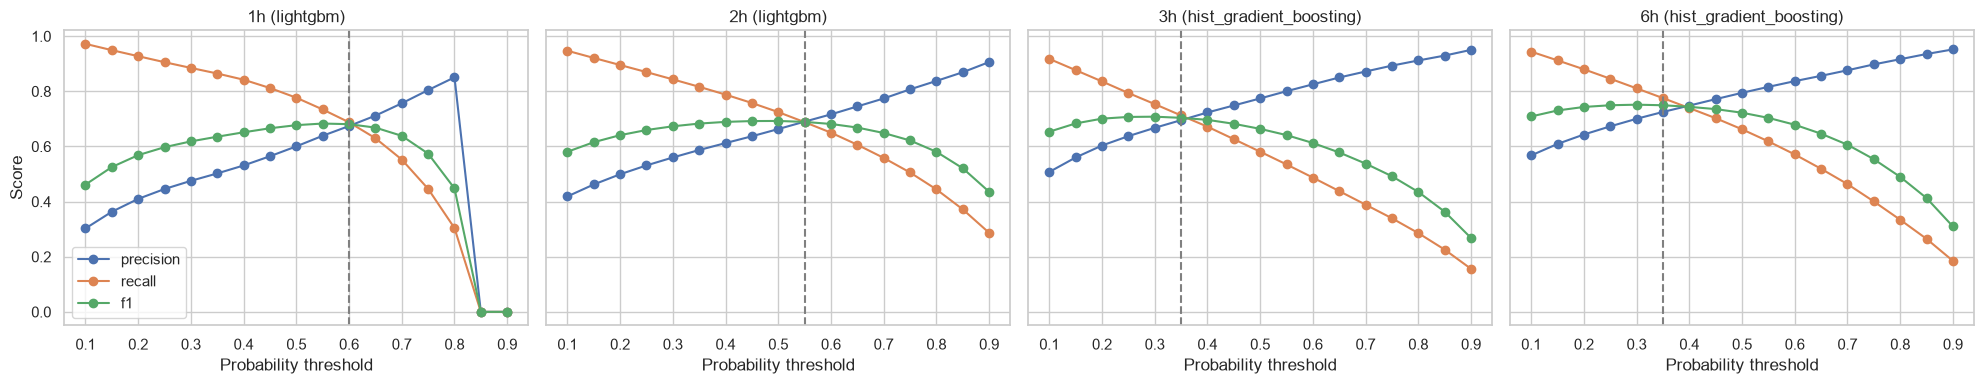

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_metrics = all_metrics[all_metrics["split"] == "test"]
sns.lineplot(data=test_metrics, x="horizon_h", y="pr_auc", marker="o", ax=axes[0])
axes[0].set_title("Bangkok Test PR-AUC By Horizon")
sns.lineplot(data=test_metrics, x="horizon_h", y="roc_auc", marker="o", ax=axes[1])
axes[1].set_title("Bangkok Test ROC-AUC By Horizon")
sns.lineplot(data=test_metrics, x="horizon_h", y="brier_score", marker="o", ax=axes[2])
axes[2].set_title("Bangkok Test Brier Score By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast window (hours)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(20, 4), sharey=True)
for ax, horizon in zip(axes, HORIZONS):
    subset = all_threshold_results[
        (all_threshold_results["horizon_h"] == horizon)
        & (all_threshold_results["split"] == "test")
    ]
    ax.plot(subset["probability_threshold"], subset["precision"], marker="o", label="precision")
    ax.plot(subset["probability_threshold"], subset["recall"], marker="o", label="recall")
    ax.plot(subset["probability_threshold"], subset["f1"], marker="o", label="f1")
    ax.axvline(SELECTED_PROBABILITY_THRESHOLDS[horizon], color="grey", linestyle="--")
    ax.set_title(f"{horizon}h ({MODEL_PLAN[horizon]})")
    ax.set_xlabel("Probability threshold")
axes[0].set_ylabel("Score")
axes[0].legend()
plt.tight_layout()
plt.show()

,model,horizon_h,feature,importance,is_neighbor_feature
29,lightgbm,1,hour_cos,249.0000,False
28,lightgbm,1,hour_sin,174.0000,False
50,lightgbm,1,neighbor_dew_point_2m_mean,157.0000,True
30,lightgbm,1,month_sin,127.0000,False
37,lightgbm,1,neighbor_precipitation_mean,125.0000,True
19,lightgbm,1,precipitation_sum_past_24h,115.0000,False
8,lightgbm,1,wind_direction_10m,106.0000,False
5,lightgbm,1,precipitation,101.0000,False
25,lightgbm,1,humidity_lag_6h,96.0000,False
4,lightgbm,1,dew_point_2m,76.0000,False


Share of LightGBM split importance coming from neighbour-grid features


is_neighbor_feature,False,True,neighbor_importance_share
horizon_h,,,
1,1624.0000,980.0000,0.3763
2,57617.0000,35383.0000,0.3805


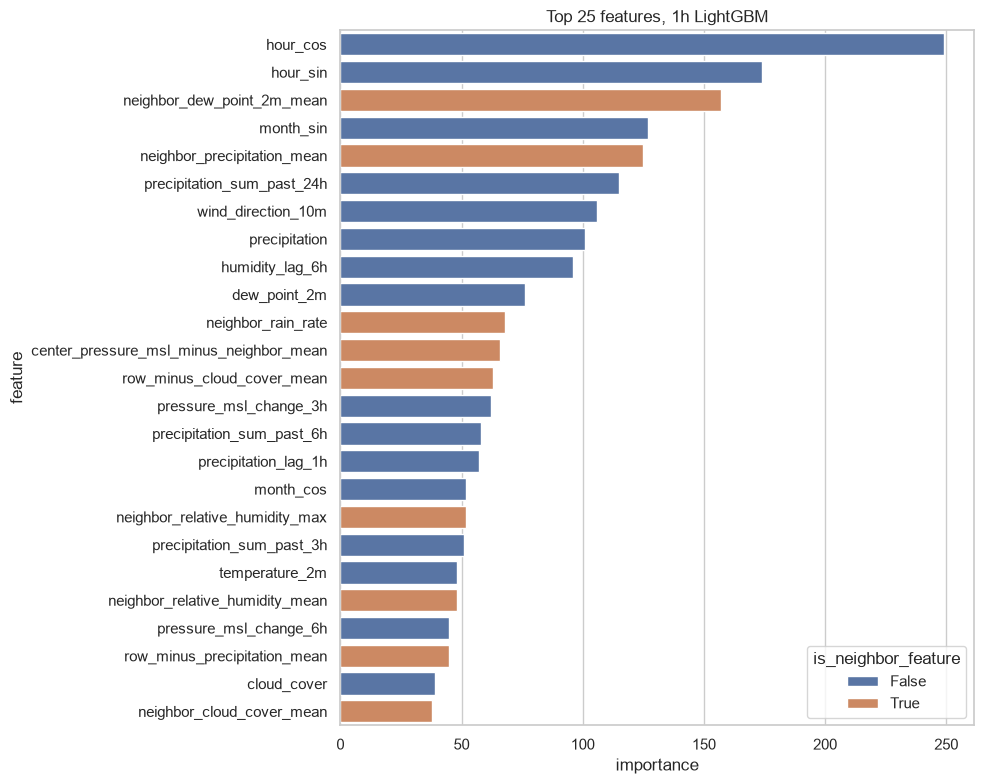

In [12]:
feature_importance = pd.DataFrame(feature_importance_rows)
if not feature_importance.empty:
    top_importance = (
        feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False])
        .groupby("horizon_h").head(20)
    )
    display(top_importance)

    neighbor_share = (
        feature_importance.groupby(["horizon_h", "is_neighbor_feature"])["importance"].sum()
        .unstack(fill_value=0.0)
        .reindex(columns=[False, True], fill_value=0.0)
    )
    neighbor_share["neighbor_importance_share"] = (
        neighbor_share[True] / neighbor_share.sum(axis=1)
    )
    print("Share of LightGBM split importance coming from neighbour-grid features")
    display(neighbor_share)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_1h = feature_importance[feature_importance["horizon_h"] == 1].nlargest(25, "importance")
    sns.barplot(data=top_1h, y="feature", x="importance",
                hue="is_neighbor_feature", dodge=False, ax=ax)
    ax.set_title("Top 25 features, 1h LightGBM")
    plt.tight_layout()
    plt.show()

## 10. Save Final Models And Results

In [13]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = SELECTED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / (
        f"om_bkk_rain_any_v1_next_{horizon}h_neighbor_grid_{model_name}"
        f"_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    )
    joblib.dump(model, path)

# The predecessor notebook's HistGradientBoosting artifacts can no longer be
# unpickled under scikit-learn 1.9 ("No module named '_loss'") because sklearn moved that
# module after they were written. Record versions so the environment can be reproduced
# rather than the models being lost.
import lightgbm
import sklearn

environment = {
    "scikit_learn": sklearn.__version__,
    "lightgbm": lightgbm.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "joblib": joblib.__version__,
}
print("environment:", environment)

target_balance.to_csv(MODEL_DIR / "bkk_rain_v1_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "bkk_rain_v1_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "bkk_rain_v1_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "bkk_rain_v1_best_thresholds_by_f1.csv", index=False)
selected_threshold_metrics.to_csv(MODEL_DIR / "bkk_rain_v1_selected_threshold_metrics.csv", index=False)
legacy_threshold_metrics.to_csv(MODEL_DIR / "bkk_rain_v1_legacy_threshold_metrics.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "bkk_rain_v1_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "region": "bangkok_9km_grid",
    "based_on": "Thailand_Rain_V1.ipynb",
    "target_type": "rain_any_within_next_n_hours",
    "target_label_source": "open_meteo_precipitation (ECMWF model output, not observed rain)",
    "model_plan": MODEL_PLAN,
    "selected_probability_thresholds": SELECTED_PROBABILITY_THRESHOLDS,
    "legacy_probability_thresholds": LEGACY_PROBABILITY_THRESHOLDS,
    "threshold_selection": "best F1 on validation split, evaluated once on test",
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "panel_end_note": "no truncation needed; all 56 Bangkok grids span 2021-07-20..2026-07-19",
    "lightgbm_early_stopping": USE_LIGHTGBM_EARLY_STOPPING,
    "hgb_early_stopping": False,
    "fitted_iterations": fitted_iterations,
    "environment": environment,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "rows": int(x_all.shape[0]),
    "grids": int(np.unique(grid_number).size),
    "train_seconds": train_timings,
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
    "selected_threshold_metrics": selected_threshold_metrics.to_dict(orient="records"),
}
(MODEL_DIR / "bkk_rain_v1_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved BKK Rain V1 models and result CSVs to {MODEL_DIR}")

environment: {'scikit_learn': '1.9.0', 'lightgbm': '4.7.0', 'numpy': '2.5.0', 'pandas': '3.0.3', 'joblib': '1.5.3'}
Saved BKK Rain V1 models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_v1


## 11. Optional: Score Against Observed Rainfall (IMERG)

Everything above grades the model against Open-Meteo `precipitation`, which is ECMWF model
output. This section re-grades the *same* predictions against `"IMERG_BKK_DATA"`, NASA's
satellite record of what actually fell, by rebuilding `rain_any` from IMERG.

Nothing here changes training and nothing already saved is overwritten - it only adds a
second scoring pass. Set `RUN_IMERG_AUDIT = False` in section 2, or delete this section,
to skip it.

Expect the numbers to drop. Running the equivalent check against the previously saved 1h
and 2h models gave ROC-AUC 0.933 -> 0.773 and precision 0.668 -> 0.261 at +1h. That gap is
the share of the reported skill that does not correspond to observed rain.

`pr_auc_lift` (PR-AUC divided by the base rate) is reported because the two label sources
have different rain frequencies, so raw precision is not comparable across them.

C:\Users\Brandon\AppData\Local\Temp\ipykernel_15016\2123333746.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  imerg = pd.read_sql_query(imerg_query, conn, parse_dates=["t"])


IMERG rows loaded: 2,453,752


matched 367,904 of 367,960 test rows to IMERG



Same predictions, scored against each label source (test split):


base_rate                f1            pr_auc_lift             \
label_source     imerg open_meteo  imerg open_meteo       imerg open_meteo   
horizon_h                                                                    
1               0.1005     0.1624 0.3332     0.6809      2.6659     4.4909   
2               0.1369     0.2184 0.3856     0.6892      2.5265     3.5079   
3               0.1686     0.2631 0.4336     0.7039      2.3482     2.9696   
6               0.2462     0.3644 0.5156     0.7494      2.0588     2.2707   

             precision            recall            roc_auc             
label_source     imerg open_meteo  imerg open_meteo   imerg open_meteo  
horizon_h                                                               
1               0.2677     0.6742 0.4412     0.6877  0.7602     0.9255  
2               0.3140     0.6900 0.4995     0.6883  0.7702     0.9118  
3               0.3524     0.6955 0.5633     0.7125  0.7685     0.9024  
6               0.4208     0.7252 0.6657     0.7753  0.7672     0.8928

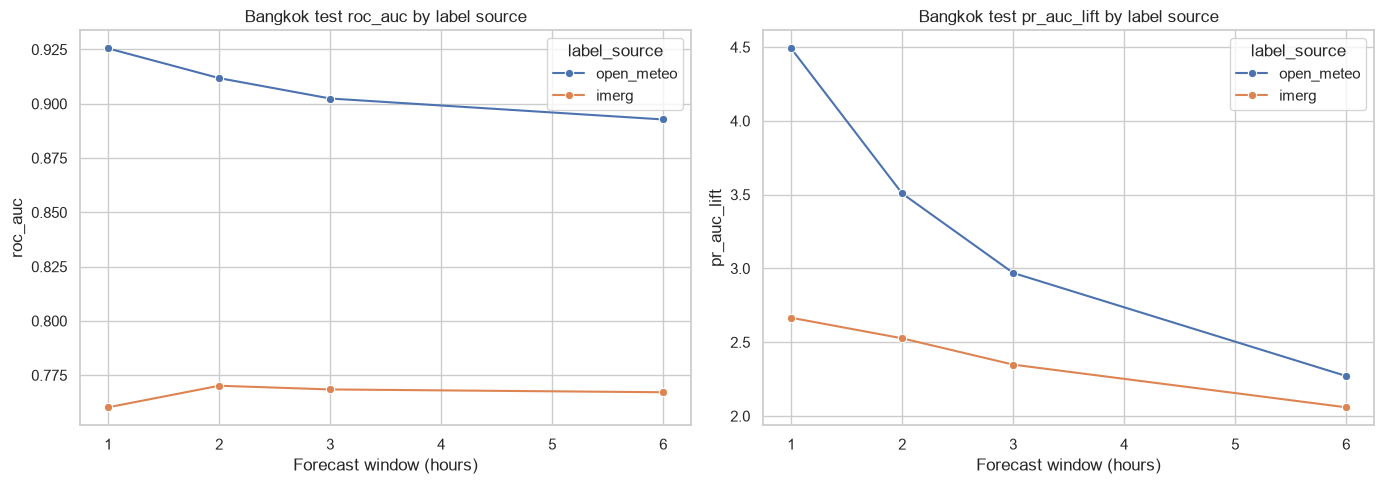

Saved audit to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_v1\bkk_rain_v1_imerg_audit.csv


In [14]:
if not RUN_IMERG_AUDIT:
    print("RUN_IMERG_AUDIT is False; skipping.")
else:
    max_h = max(HORIZONS)
    lead_sql = ",\n            ".join(
        f"LEAD(precipitation_mm, {h}) OVER w AS imerg_next_{h}h" for h in range(1, max_h + 1)
    )
    lead_cols = ", ".join(f"imerg_next_{h}h" for h in range(1, max_h + 1))
    imerg_query = (
        "WITH iw AS (\n"
        "    SELECT grid_number, local_observation_time AS t,\n"
        f"        {lead_sql}\n"
        f"    FROM {IMERG_TABLE_NAME}\n"
        "    WHERE is_complete_hour\n"
        "    WINDOW w AS (PARTITION BY grid_number ORDER BY local_observation_time)\n"
        ")\n"
        f"SELECT grid_number, t, {lead_cols}\n"
        "FROM iw\n"
        f"WHERE imerg_next_{max_h}h IS NOT NULL\n"
        "ORDER BY t, grid_number"
    )
    with connect() as conn:
        imerg = pd.read_sql_query(imerg_query, conn, parse_dates=["t"])
    print(f"IMERG rows loaded: {len(imerg):,}")

    # Align IMERG onto the exact test rows by (grid_number, time).
    test_keys = pd.DataFrame({
        "grid_number": grid_number[validation_stop:],
        "t": forecast_time[validation_stop:],
    })
    test_keys["row_order"] = np.arange(len(test_keys))
    aligned = test_keys.merge(imerg, on=["grid_number", "t"], how="inner").sort_values("row_order")
    print(f"matched {len(aligned):,} of {len(test_keys):,} test rows to IMERG")

    take = aligned["row_order"].to_numpy()
    audit_rows = []
    for index, horizon in enumerate(HORIZONS):
        probabilities = models[horizon].predict_proba(x_test[take])[:, 1]
        threshold = SELECTED_PROBABILITY_THRESHOLDS[horizon]
        predictions = (probabilities >= threshold).astype("int8")

        imerg_any = (
            aligned[[f"imerg_next_{k}h" for k in range(1, horizon + 1)]] >= RAIN_THRESHOLD_MM
        ).any(axis=1).astype("int8").to_numpy()
        om_any = y_test_all[take, index]

        for source, y_true in [("open_meteo", om_any), ("imerg", imerg_any)]:
            base_rate = float(np.mean(y_true))
            pr_auc = float(average_precision_score(y_true, probabilities))
            audit_rows.append({
                "horizon_h": horizon,
                "label_source": source,
                "rows": int(len(y_true)),
                "base_rate": base_rate,
                "roc_auc": float(roc_auc_score(y_true, probabilities)),
                "pr_auc": pr_auc,
                "pr_auc_lift": pr_auc / base_rate if base_rate else float("nan"),
                "precision": float(precision_score(y_true, predictions, zero_division=0)),
                "recall": float(recall_score(y_true, predictions, zero_division=0)),
                "f1": float(f1_score(y_true, predictions, zero_division=0)),
            })

    imerg_audit = pd.DataFrame(audit_rows)
    imerg_audit.to_csv(MODEL_DIR / "bkk_rain_v1_imerg_audit.csv", index=False)

    print("\nSame predictions, scored against each label source (test split):")
    display(imerg_audit.pivot_table(
        index="horizon_h", columns="label_source",
        values=["base_rate", "roc_auc", "pr_auc_lift", "precision", "recall", "f1"],
    ))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ["roc_auc", "pr_auc_lift"]):
        sns.lineplot(data=imerg_audit, x="horizon_h", y=metric, hue="label_source",
                     marker="o", ax=ax)
        ax.set_title(f"Bangkok test {metric} by label source")
        ax.set_xlabel("Forecast window (hours)")
    plt.tight_layout()
    plt.show()
    print(f"Saved audit to {MODEL_DIR / 'bkk_rain_v1_imerg_audit.csv'}")